In [2]:
import numpy as np
from astropy.time import Time
from astropy.coordinates import EarthLocation
import astropy.units as u

mu = 398600.4418  # km^3/s^2


# -----------------------------
# Conversions
# -----------------------------
def ra_dec_to_unit_vector(ra_deg, dec_deg):
    ra = np.radians(ra_deg)
    dec = np.radians(dec_deg)
    return np.array([
        np.cos(dec)*np.cos(ra),
        np.cos(dec)*np.sin(ra),
        np.sin(dec)
    ])


def observer_position_eci(lat, lon, alt, time):
    loc = EarthLocation(lat=lat*u.deg, lon=lon*u.deg, height=alt*u.m)
    gcrs = loc.get_gcrs(Time(time))
    return np.array([
        gcrs.cartesian.x.to(u.km).value,
        gcrs.cartesian.y.to(u.km).value,
        gcrs.cartesian.z.to(u.km).value
    ])


# -----------------------------
# Gibbs velocity (stable)
# -----------------------------
def gibbs_velocity(r1, r2, r3):
    r1n = np.linalg.norm(r1)
    r2n = np.linalg.norm(r2)
    r3n = np.linalg.norm(r3)

    c12 = np.cross(r1, r2)
    c23 = np.cross(r2, r3)
    c31 = np.cross(r3, r1)

    N = r1n*c23 + r2n*c31 + r3n*c12
    D = c12 + c23 + c31
    S = r1*(r2n - r3n) + r2*(r3n - r1n) + r3*(r1n - r2n)

    if np.linalg.norm(N) == 0 or np.linalg.norm(D) == 0:
        raise ValueError("Gibbs method failed (coplanar or bad geometry)")

    v2 = np.sqrt(mu / (np.linalg.norm(N)*np.linalg.norm(D))) * (np.cross(D, r2)/r2n + S)

    return v2


In [3]:
# -----------------------------
# Gauss Method (corrected)
# -----------------------------
def gauss_method(obs, lat, lon, alt):
    t = [Time(o["time"]) for o in obs]

    tau1 = (t[0] - t[1]).sec
    tau3 = (t[2] - t[1]).sec
    tau = tau3 - tau1

    L = [ra_dec_to_unit_vector(o["ra"], o["dec"]) for o in obs]
    R = [observer_position_eci(lat, lon, alt, o["time"]) for o in obs]

    def det(a, b, c):
        return np.dot(a, np.cross(b, c))

    D0 = det(L[0], L[1], L[2])
    if abs(D0) < 1e-8:
        raise ValueError("Bad geometry: LOS vectors nearly coplanar")

    D = np.zeros((3,3))
    for i in range(3):
        D[i,0] = det(R[i], L[1], L[2])
        D[i,1] = det(L[0], R[i], L[2])
        D[i,2] = det(L[0], L[1], R[i])

    # Initial guess
    r2_mag = 6700.0

    for _ in range(10):  # iteration loop
        f1 = 1 - (mu * tau1**2) / (2 * r2_mag**3)
        f3 = 1 - (mu * tau3**2) / (2 * r2_mag**3)

        g1 = tau1 - (mu * tau1**3) / (6 * r2_mag**3)
        g3 = tau3 - (mu * tau3**3) / (6 * r2_mag**3)

        den = (f1*g3 - f3*g1)
        if abs(den) < 1e-8:
            raise ValueError("Numerical instability in iteration")

        c1 = g3 / den
        c3 = -g1 / den

        rho1 = (c1*D[0,0] - D[1,0] + c3*D[2,0]) / (c1*D0)
        rho2 = (c1*D[0,1] - D[1,1] + c3*D[2,1]) / (c1*D0)
        rho3 = (c1*D[0,2] - D[1,2] + c3*D[2,2]) / (c1*D0)

        r1 = R[0] + rho1 * L[0]
        r2 = R[1] + rho2 * L[1]
        r3 = R[2] + rho3 * L[2]

        r2_mag_new = np.linalg.norm(r2)

        if abs(r2_mag_new - r2_mag) < 1e-6:
            break

        r2_mag = r2_mag_new

    # Final velocity using Gibbs (much more stable)
    v2 = gibbs_velocity(r1, r2, r3)

    return r2, v2

In [4]:
# -----------------------------
# User Inputs (Editable)
# -----------------------------

# Times (UTC, ISO format)
t1 = "2026-04-27T10:00:00"
t2 = "2026-04-27T10:00:0.5"
t3 = "2026-04-27T10:00:1"

# RA (hh, mm, ss)
ra1_h, ra1_m, ra1_s = 8, 13, 24
ra2_h, ra2_m, ra2_s = 8, 13, 5
ra3_h, ra3_m, ra3_s = 8, 12, 47

# Dec (deg, arcmin, arcsec) — include sign in degrees
dec1_d, dec1_m, dec1_s = 5, 12, 17
dec2_d, dec2_m, dec2_s = 4, 57, 31
dec3_d, dec3_m, dec3_s = 4, 42, 26


# -----------------------------
# Conversion Functions
# -----------------------------

def ra_hms_to_deg(h, m, s):
    return 15.0 * (h + m/60.0 + s/3600.0)

def dec_dms_to_deg(d, m, s):
    sign = np.sign(d)
    return d + sign * (m/60.0 + s/3600.0)


# -----------------------------
# Converted Values (used in obs)
# -----------------------------

ra1 = ra_hms_to_deg(ra1_h, ra1_m, ra1_s)
ra2 = ra_hms_to_deg(ra2_h, ra2_m, ra2_s)
ra3 = ra_hms_to_deg(ra3_h, ra3_m, ra3_s)

dec1 = dec_dms_to_deg(dec1_d, dec1_m, dec1_s)
dec2 = dec_dms_to_deg(dec2_d, dec2_m, dec2_s)
dec3 = dec_dms_to_deg(dec3_d, dec3_m, dec3_s)

obs = [
    {"time": t1, "ra": ra1, "dec": dec1},
    {"time": t2, "ra": ra2, "dec": dec2},
    {"time": t3, "ra": ra3, "dec": dec3},
]

lat = 17.59     # degrees
lon = 78.15     # degrees
alt = 500      # meters



r2, v2 = gauss_method(obs, lat, lon, alt)



print("Position (km):", r2)
print("Velocity (km/s):", v2)

Position (km): [ 704.62616285 6067.50012718 1916.1348668 ]
Velocity (km/s): [ 0.01851123 -0.06439147  0.00071365]


In [5]:
# -----------------------------
# Estimate C1, C2, tau_opt
# -----------------------------

# --- 1. Time differences ---
t = [Time(o["time"]) for o in obs]
tau1 = (t[0] - t[1]).sec
tau3 = (t[2] - t[1]).sec

# use symmetric effective tau
tau_eff = (abs(tau1) + abs(tau3)) / 2.0


# --- 2. LOS vectors ---
L = [ra_dec_to_unit_vector(o["ra"], o["dec"]) for o in obs]


# --- 3. Estimate angular rate |d(rho_hat)/dt| ---
# central difference approximation
rho_dot = (L[2] - L[0]) / (t[2] - t[0]).sec
rho_dot_norm = np.linalg.norm(rho_dot)


# --- 4. Observer position magnitude ---
R2_vec = observer_position_eci(lat, lon, alt, obs[1]["time"])
R2_norm = np.linalg.norm(R2_vec)


# --- 5. Estimate angular noise sigma_theta ---
# You should replace this with your detector accuracy
# Example: 5 arcsec ≈ 5 * (pi / 648000) rad
sigma_arcsec = 3.2
sigma_theta = sigma_arcsec * (np.pi / (180.0 * 3600.0))


# --- 6. Compute C1 ---
C1 = (sigma_theta**2 * R2_norm**2) / (rho_dot_norm**2 + 1e-12)


# --- 7. Compute C2 ---
r2_norm = np.linalg.norm(r2)
C2 = (mu**2) / (r2_norm**5 + 1e-12)


# --- 8. Optimal tau ---
tau_opt = (C1 / (2 * C2))**(1/6)


# -----------------------------
# Print results
# -----------------------------
print("\n--- Error Model Parameters ---")
print(f"sigma_theta (rad): {sigma_theta:.3e}")
print(f"|rho_dot| (rad/s): {rho_dot_norm:.3e}")
print(f"|R2| (km): {R2_norm:.3f}")
print(f"|r2| (km): {r2_norm:.3f}")

print("\nC1:", C1)
print("C2:", C2)
print("\nCurrent tau (s):", tau_eff)
print("Optimal tau (s):", tau_opt)


--- Error Model Parameters ---
sigma_theta (rad): 1.551e-05
|rho_dot| (rad/s): 9.087e-03
|R2| (km): 6376.699
|r2| (km): 6401.768

C1: 118.51314390944977
C2: 1.477665127751649e-08

Current tau (s): 0.49999999999847944
Optimal tau (s): 39.85903222776181


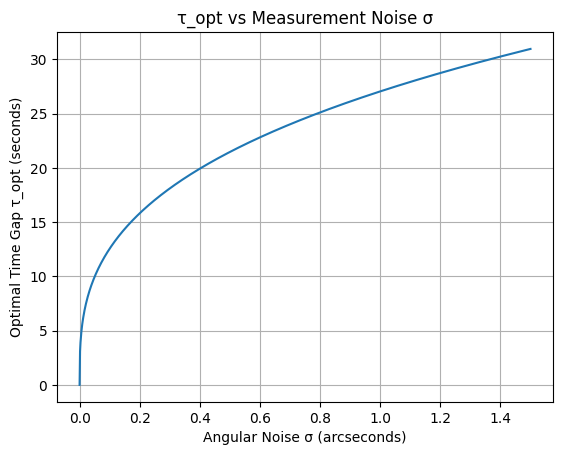

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Prepare fixed quantities
# -----------------------------
 
# Time objects
t = [Time(o["time"]) for o in obs]

# LOS vectors
L = [ra_dec_to_unit_vector(o["ra"], o["dec"]) for o in obs]

# Angular rate (central difference)
dt_total = (t[2] - t[0]).sec
rho_dot = (L[2] - L[0]) / dt_total
rho_dot_norm = np.linalg.norm(rho_dot)

# Observer position magnitude
R2_vec = observer_position_eci(lat, lon, alt, obs[1]["time"])
R2_norm = np.linalg.norm(R2_vec)

# Satellite distance
r2_norm = np.linalg.norm(r2)

# C2 (constant)
C2 = (mu**2) / (r2_norm**5 + 1e-12)

# -----------------------------
# Sweep sigma (arcseconds)
# -----------------------------
sigma_arcsec_range = np.linspace(0, 1.5, 1000)  # 0.1 to 50 arcsec
tau_opt_list = []

for sigma_arcsec in sigma_arcsec_range:
    
    sigma_theta = sigma_arcsec * (np.pi / (180.0 * 3600.0))  # to radians
    
    # C1
    C1 = (sigma_theta**2 * R2_norm**2) / (rho_dot_norm**2 + 1e-12)
    
    # tau_opt
    tau_opt = (C1 / (2 * C2))**(1/6)
    
    tau_opt_list.append(tau_opt)

# -----------------------------
# Plot
# -----------------------------
plt.figure()
plt.plot(sigma_arcsec_range, tau_opt_list)

plt.xlabel("Angular Noise σ (arcseconds)")
plt.ylabel("Optimal Time Gap τ_opt (seconds)")
plt.title("τ_opt vs Measurement Noise σ")

plt.grid()
plt.show()

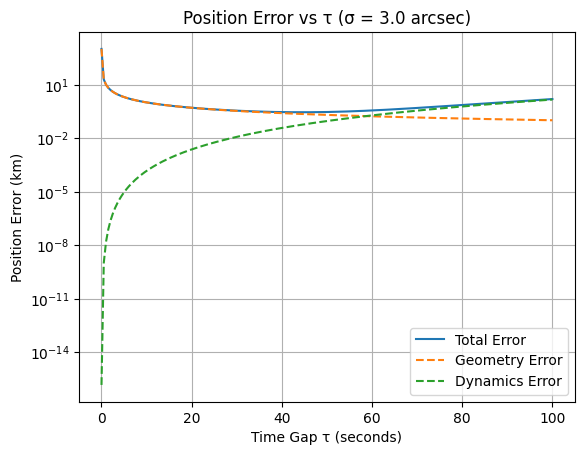

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Fixed quantities from your data
# -----------------------------

t = [Time(o["time"]) for o in obs]

# LOS vectors
L = [ra_dec_to_unit_vector(o["ra"], o["dec"]) for o in obs]

# Angular rate
dt_total = (t[2] - t[0]).sec
rho_dot = (L[2] - L[0]) / dt_total
rho_dot_norm = np.linalg.norm(rho_dot)

# Observer position
R2_vec = observer_position_eci(lat, lon, alt, obs[1]["time"])
R2_norm = np.linalg.norm(R2_vec)

# Satellite distance
r2_norm = np.linalg.norm(r2)

# -----------------------------
# USER: set your measurement noise
# -----------------------------
sigma_arcsec = 3.0   # change this
sigma_theta = sigma_arcsec * (np.pi / (180.0 * 3600.0))

# -----------------------------
# Tau range (seconds)
# -----------------------------
tau_range = np.linspace(0.01, 100, 200)  # 1 sec to 5 min

E_total = []
E_geom = []
E_dyn = []

for tau in tau_range:
    
    # Geometry error (km)
    Eg = (R2_norm * sigma_theta) / (rho_dot_norm * tau + 1e-12)
    
    # Dynamics error (km)
    Ed = (mu**2 / (r2_norm**5 + 1e-12)) * (tau**4)
    
    E_total.append(Eg + Ed)
    E_geom.append(Eg)
    E_dyn.append(Ed)

# -----------------------------
# Plot
# -----------------------------
plt.figure()

plt.plot(tau_range, E_total, label="Total Error")
plt.plot(tau_range, E_geom, linestyle='--', label="Geometry Error")
plt.plot(tau_range, E_dyn, linestyle='--', label="Dynamics Error")

plt.xlabel("Time Gap τ (seconds)")
plt.ylabel("Position Error (km)")
plt.title(f"Position Error vs τ (σ = {sigma_arcsec} arcsec)")

plt.yscale("log")  # IMPORTANT: wide range visibility
plt.legend()
plt.grid()

plt.show()

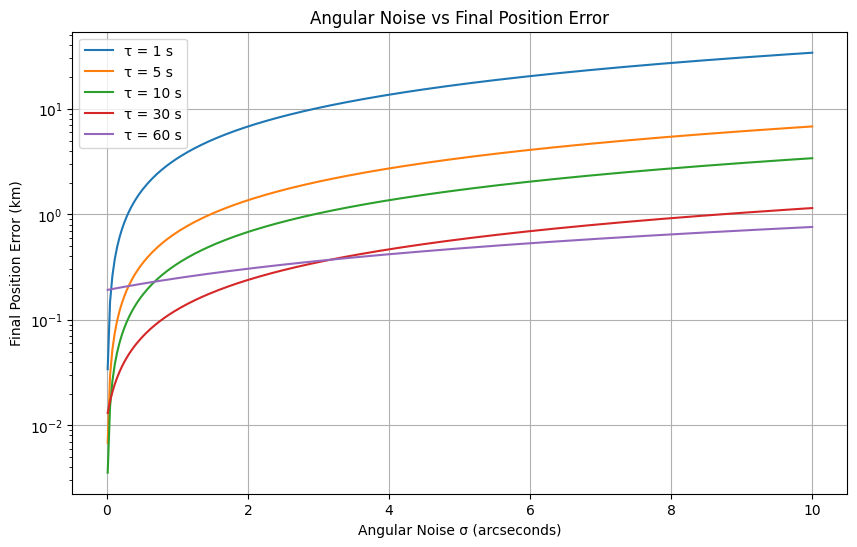

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Fixed quantities from your observation set
# =====================================================

# Time objects
t = [Time(o["time"]) for o in obs]

# LOS vectors
L = [ra_dec_to_unit_vector(o["ra"], o["dec"]) for o in obs]

# Angular rate
dt_total = (t[2] - t[0]).sec
rho_dot = (L[2] - L[0]) / dt_total
rho_dot_norm = np.linalg.norm(rho_dot)

# Observer position magnitude
R2_vec = observer_position_eci(lat, lon, alt, obs[1]["time"])
R2_norm = np.linalg.norm(R2_vec)

# Satellite distance magnitude
r2_norm = np.linalg.norm(r2)

# =====================================================
# Angular noise range (arcseconds)
# =====================================================

sigma_arcsec_range = np.linspace(0.01, 10, 300)

# =====================================================
# Different tau values to compare
# =====================================================

tau_values = [1, 5, 10, 30, 60]

# =====================================================
# Plot
# =====================================================

plt.figure(figsize=(10,6))

for tau in tau_values:

    E_total = []

    for sigma_arcsec in sigma_arcsec_range:

        # Convert arcsec -> radians
        sigma_theta = sigma_arcsec * (np.pi / (180.0 * 3600.0))

        # ---------------------------------------------
        # Geometry error (km)
        # ---------------------------------------------
        E_geom = (
            (R2_norm * sigma_theta)
            / (rho_dot_norm * tau + 1e-12)
        )

        # ---------------------------------------------
        # Dynamics error (km)
        # ---------------------------------------------
        E_dyn = (
            (mu**2 / (r2_norm**5 + 1e-12))
            * (tau**4)
        )

        # ---------------------------------------------
        # Total error
        # ---------------------------------------------
        E = E_geom + E_dyn

        E_total.append(E)

    plt.plot(
        sigma_arcsec_range,
        E_total,
        label=f"τ = {tau} s"
    )

# =====================================================
# Formatting
# =====================================================

plt.xlabel("Angular Noise σ (arcseconds)")
plt.ylabel("Final Position Error (km)")
plt.title("Angular Noise vs Final Position Error")

plt.yscale("log")  # IMPORTANT for visibility
plt.grid()
plt.legend()

plt.show()